C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_17780\924161997.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='요일_한글', y='일일평균혼잡도', order=order, palette='viridis')


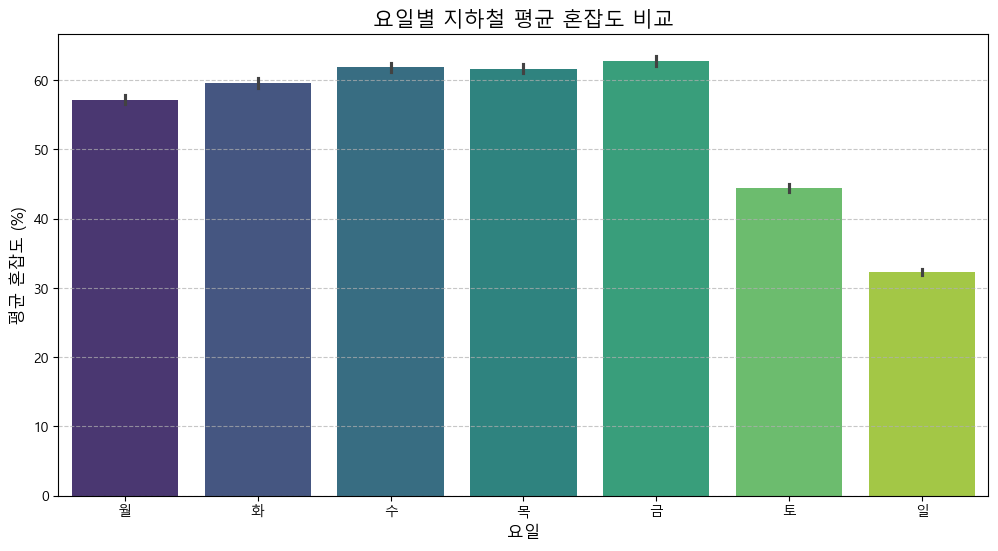

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (환경에 따라 'AppleGothic' 또는 'Malgun Gothic' 사용)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 데이터 불러오기
df = pd.read_csv('서울교통공사_시간대별_추정혼잡도(%).csv', encoding='utf8')

# 1. 날짜 처리: '수송일자'를 datetime 객체로 변환
df['수송일자'] = pd.to_datetime(df['수송일자'])

# 2. 요일 정보 추출 (0=월, 1=화, ..., 6=일) 및 한글 요일 매핑
df['요일'] = df['수송일자'].dt.dayofweek
weekday_map = {0: '월', 1: '화', 2: '수', 3: '목', 4: '금', 5: '토', 6: '일'}
df['요일_한글'] = df['요일'].map(weekday_map)

# 3. 시간대별 혼잡도 컬럼(06시이전 ~ 24시이후) 리스트 생성
time_cols = [col for col in df.columns if '시간대' in col or '이전' in col or '이후' in col]

# 4. 요일별 전체 시간대 평균 혼잡도 계산
# 모든 시간대 컬럼의 평균을 낸 '일일평균혼잡도' 생성
df['일일평균혼잡도'] = df[time_cols].mean(axis=1)

# 요일 순서대로 정렬하기 위한 리스트
order = ['월', '화', '수', '목', '금', '토', '일']

# 5. 시각화
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='요일_한글', y='일일평균혼잡도', order=order, palette='viridis')

plt.title('요일별 지하철 평균 혼잡도 비교', fontsize=15)
plt.xlabel('요일', fontsize=12)
plt.ylabel('평균 혼잡도 (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

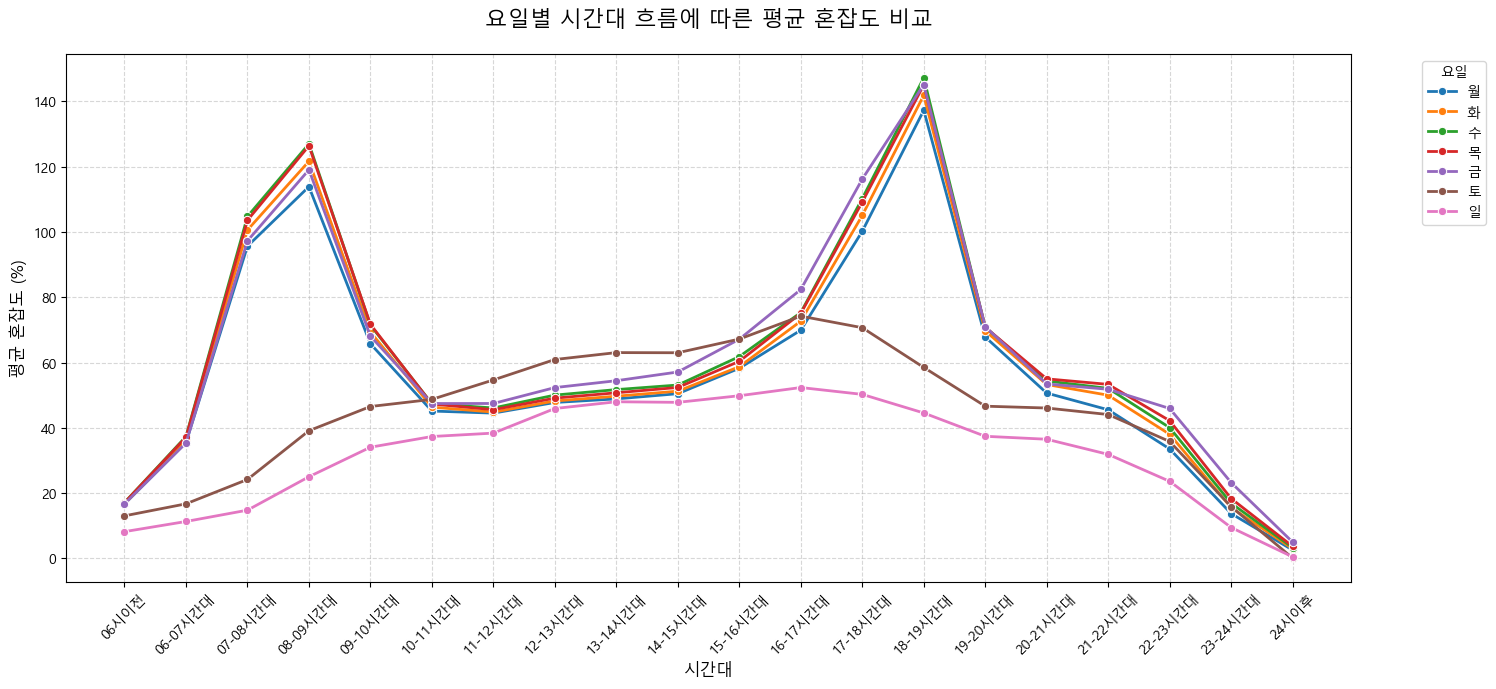

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 및 마이너스 기호 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. 데이터 불러오기 및 전처리
df = pd.read_csv('서울교통공사_시간대별_추정혼잡도(%).csv', encoding='utf8')
df['수송일자'] = pd.to_datetime(df['수송일자'])

# 요일 추출 및 정렬을 위한 설정
df['요일'] = df['수송일자'].dt.dayofweek
weekday_map = {0: '월', 1: '화', 2: '수', 3: '목', 4: '금', 5: '토', 6: '일'}
df['요일_한글'] = df['요일'].map(weekday_map)

# 2. 시간대 컬럼 추출 (06시이전 ~ 24시이후)
time_cols = [col for col in df.columns if '시간대' in col or '이전' in col or '이후' in col]

# 3. 요일별 시간대 평균 계산
# 요일과 시간대 컬럼만 선택하여 평균 산출
df_weekly_time = df.groupby('요일_한글')[time_cols].mean().reindex(['월', '화', '수', '목', '금', '토', '일'])

# 4. 시각화를 위해 데이터 재구조화 (Tidy Data 형식으로 변환)
df_plot = df_weekly_time.reset_index().melt(id_vars='요일_한글', var_name='시간대', value_name='혼잡도')

# 5. 그래프 그리기
plt.figure(figsize=(15, 7))
sns.lineplot(data=df_plot, x='시간대', y='혼잡도', hue='요일_한글', marker='o', linewidth=2)

plt.title('요일별 시간대 흐름에 따른 평균 혼잡도 비교', fontsize=16, pad=20)
plt.xlabel('시간대', fontsize=12)
plt.ylabel('평균 혼잡도 (%)', fontsize=12)
plt.xticks(rotation=45) # 시간대 이름이 겹치지 않게 회전
plt.legend(title='요일', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_17780\2327246066.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged_df, x='비여부', y='일평균혼잡도', palette='Set2')


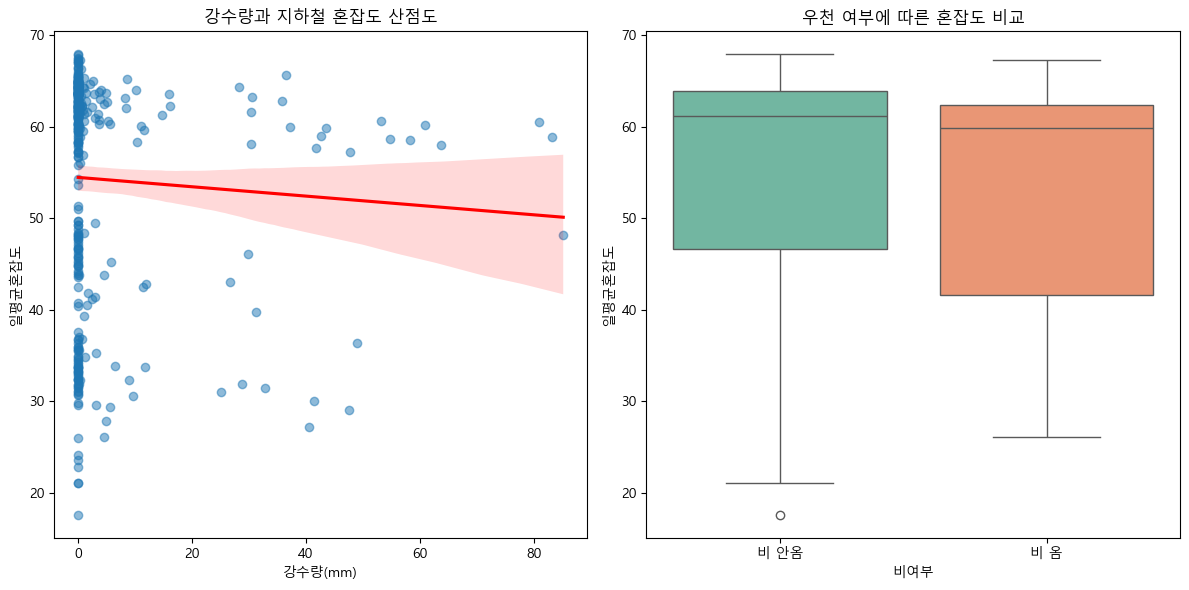

강수량과 혼잡도의 상관계수: -0.0527


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. 데이터 불러오기
df_subway = pd.read_csv('서울교통공사_시간대별_추정혼잡도(%).csv', encoding='utf8')
df_weather = pd.read_csv('서울_기상데이터_2023.csv', encoding='cp949')

# 2. 날짜 데이터 전처리
df_subway['수송일자'] = pd.to_datetime(df_subway['수송일자'])
df_weather['일시'] = pd.to_datetime(df_weather['일시'])

# 기상 데이터에서 '날짜'만 추출하여 일별 총 강수량 계산
df_weather['날짜'] = df_weather['일시'].dt.date
daily_rain = df_weather.groupby('날짜')['강수량(mm)'].sum().reset_index()
daily_rain['날짜'] = pd.to_datetime(daily_rain['날짜'])

# 3. 지하철 데이터 일별 평균 혼잡도 계산
time_cols = [col for col in df_subway.columns if '시간대' in col or '이전' in col or '이후' in col]
df_subway['일평균혼잡도'] = df_subway[time_cols].mean(axis=1)
daily_subway = df_subway.groupby('수송일자')['일평균혼잡도'].mean().reset_index()

# 4. 데이터 병합 (날짜 기준)
merged_df = pd.merge(daily_subway, daily_rain, left_on='수송일자', right_on='날짜').drop('날짜', axis=1)

# 강수량 유무에 따른 구분 (비 오는 날 vs 안 오는 날)
merged_df['비여부'] = merged_df['강수량(mm)'].apply(lambda x: '비 안옴' if x == 0 else '비 옴')

# 5. 시각화
plt.figure(figsize=(12, 6))

# (1) 산점도 및 회귀선: 강수량과 혼잡도의 상관관계
plt.subplot(1, 2, 1)
sns.regplot(data=merged_df, x='강수량(mm)', y='일평균혼잡도', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('강수량과 지하철 혼잡도 산점도')

# (2) 박스플롯: 비 오는 날 vs 안 오는 날 혼잡도 비교
plt.subplot(1, 2, 2)
sns.boxplot(data=merged_df, x='비여부', y='일평균혼잡도', palette='Set2')
plt.title('우천 여부에 따른 혼잡도 비교')

plt.tight_layout()
plt.show()

# 6. 상관계수 출력
print(f"강수량과 혼잡도의 상관계수: {merged_df['강수량(mm)'].corr(merged_df['일평균혼잡도']):.4f}")

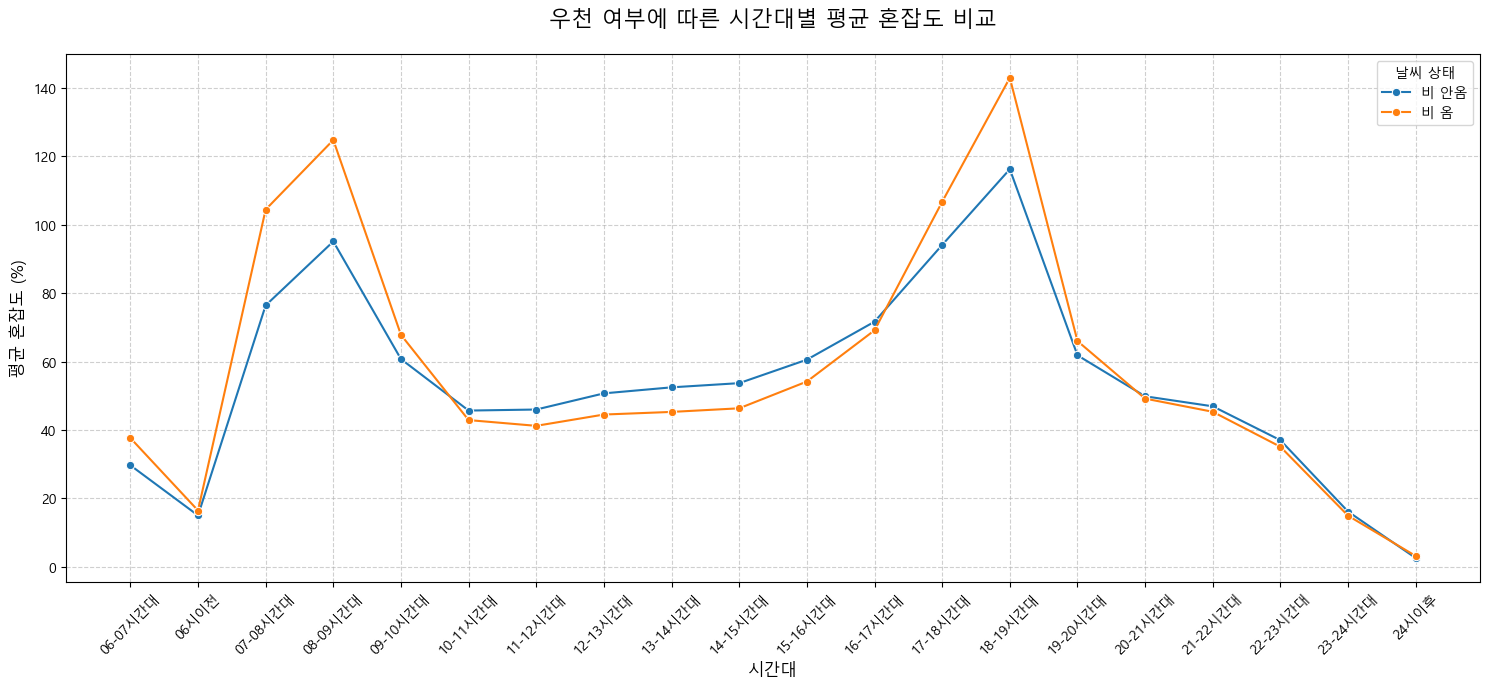

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. 데이터 불러오기
df_subway = pd.read_csv('서울교통공사_시간대별_추정혼잡도(%).csv', encoding='utf8')
df_weather = pd.read_csv('서울_기상데이터_2023.csv', encoding='cp949')

# 2. 날짜 및 시간 전처리
df_subway['수송일자'] = pd.to_datetime(df_subway['수송일자'])
df_weather['일시'] = pd.to_datetime(df_weather['일시'])

# 기상 데이터에서 일별 강수량 합계 계산 (0보다 크면 비가 온 날로 간주)
df_weather['날짜'] = df_weather['일시'].dt.date
daily_rain = df_weather.groupby('날짜')['강수량(mm)'].sum().reset_index()
daily_rain['날짜'] = pd.to_datetime(daily_rain['날짜'])
daily_rain['비여부'] = daily_rain['강수량(mm)'].apply(lambda x: '비 옴' if x >= 50 else '비 안옴')

# 3. 지하철 데이터와 기상 데이터 병합
merged_df = pd.merge(df_subway, daily_rain[['날짜', '비여부']], left_on='수송일자', right_on='날짜')

# 4. 시간대별 컬럼 추출 및 데이터 재구조화 (Tidy Data)
time_cols = [col for col in df_subway.columns if '시간대' in col or '이전' in col or '이후' in col]

# 비여부 및 시간대별 평균 혼잡도 계산
df_melted = merged_df.melt(id_vars=['비여부'], value_vars=time_cols, var_name='시간대', value_name='혼잡도')
df_comparison = df_melted.groupby(['비여부', '시간대'])['혼잡도'].mean().reset_index()

# 5. 시각화
plt.figure(figsize=(15, 7))
sns.lineplot(data=df_comparison, x='시간대', y='혼잡도', hue='비여부', marker='o', palette=['#1f77b4', '#ff7f0e'])

plt.title('우천 여부에 따른 시간대별 평균 혼잡도 비교', fontsize=16, pad=20)
plt.xlabel('시간대', fontsize=12)
plt.ylabel('평균 혼잡도 (%)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='날씨 상태')
plt.tight_layout()
plt.show()

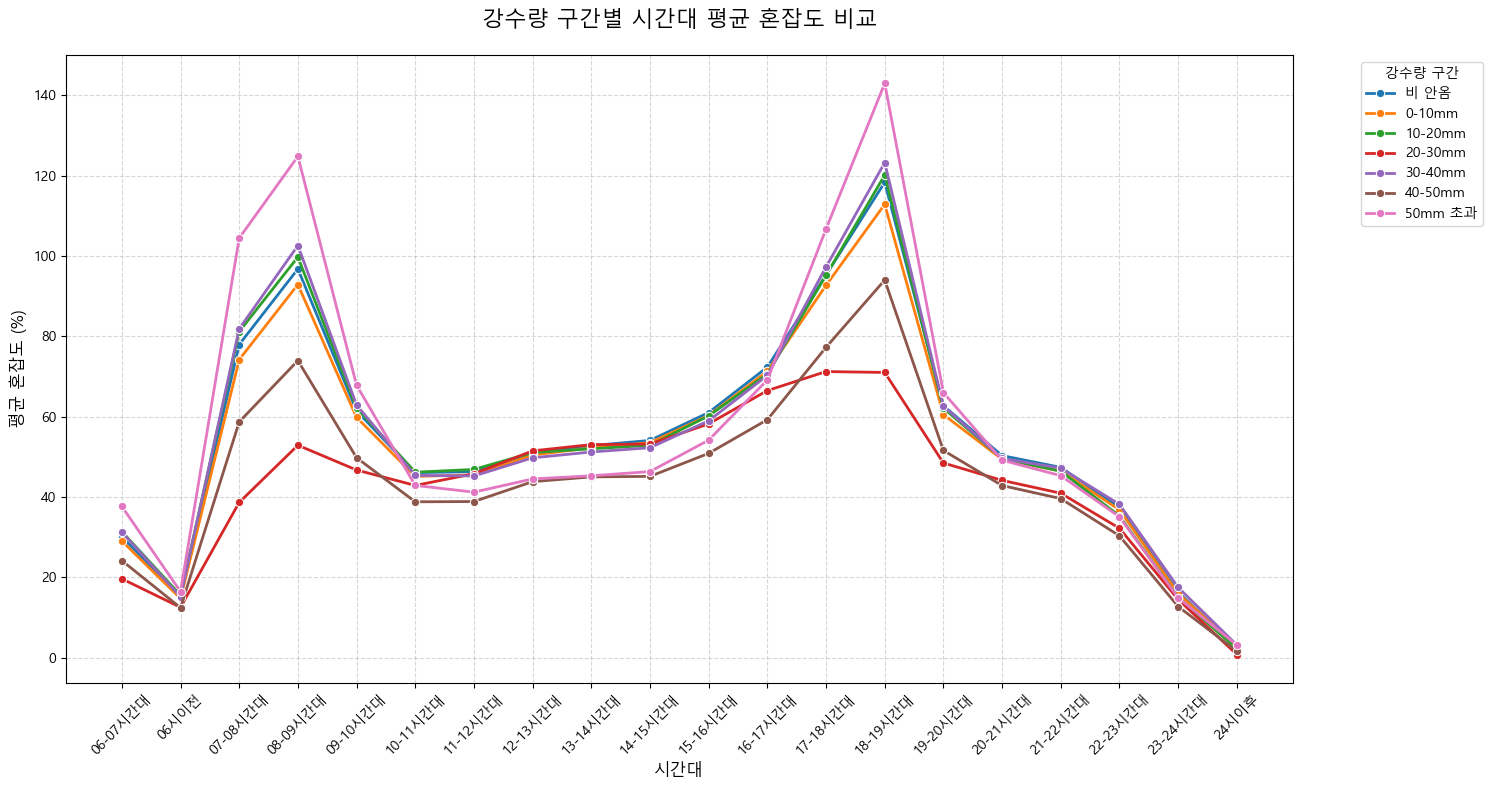

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. 데이터 불러오기
df_subway = pd.read_csv('서울교통공사_시간대별_추정혼잡도(%).csv', encoding='utf8')
df_weather = pd.read_csv('서울_기상데이터_2023.csv', encoding='cp949')

# 2. 날짜 전처리 및 일별 강수량 계산
df_subway['수송일자'] = pd.to_datetime(df_subway['수송일자'])
df_weather['일시'] = pd.to_datetime(df_weather['일시'])
df_weather['날짜'] = df_weather['일시'].dt.date

daily_rain = df_weather.groupby('날짜')['강수량(mm)'].sum().reset_index()
daily_rain['날짜'] = pd.to_datetime(daily_rain['날짜'])

# 3. 강수량 10 단위 구간(Binning) 생성
# 0, 10, 20, 30, 40, 50, 100+ mm 구간으로 나눔
bins = [0, 0.1, 10, 20, 30, 40, 50, 1000]
labels = ['비 안옴', '0-10mm', '10-20mm', '20-30mm', '30-40mm', '40-50mm', '50mm 초과']
daily_rain['강수구간'] = pd.cut(daily_rain['강수량(mm)'], bins=bins, labels=labels, include_lowest=True, right=False)

# 4. 데이터 병합
merged_df = pd.merge(df_subway, daily_rain[['날짜', '강수구간']], left_on='수송일자', right_on='날짜')

# 5. 시간대별 데이터 재구조화
time_cols = [col for col in df_subway.columns if '시간대' in col or '이전' in col or '이후' in col]
df_melted = merged_df.melt(id_vars=['강수구간'], value_vars=time_cols, var_name='시간대', value_name='혼잡도')

# 강수구간 및 시간대별 평균 계산
df_grouped = df_melted.groupby(['강수구간', '시간대'], observed=True)['혼잡도'].mean().reset_index()

# 6. 시각화
plt.figure(figsize=(15, 8))
sns.lineplot(data=df_grouped, x='시간대', y='혼잡도', hue='강수구간', marker='o', linewidth=2)

plt.title('강수량 구간별 시간대 평균 혼잡도 비교', fontsize=16, pad=20)
plt.xlabel('시간대', fontsize=12)
plt.ylabel('평균 혼잡도 (%)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='강수량 구간', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

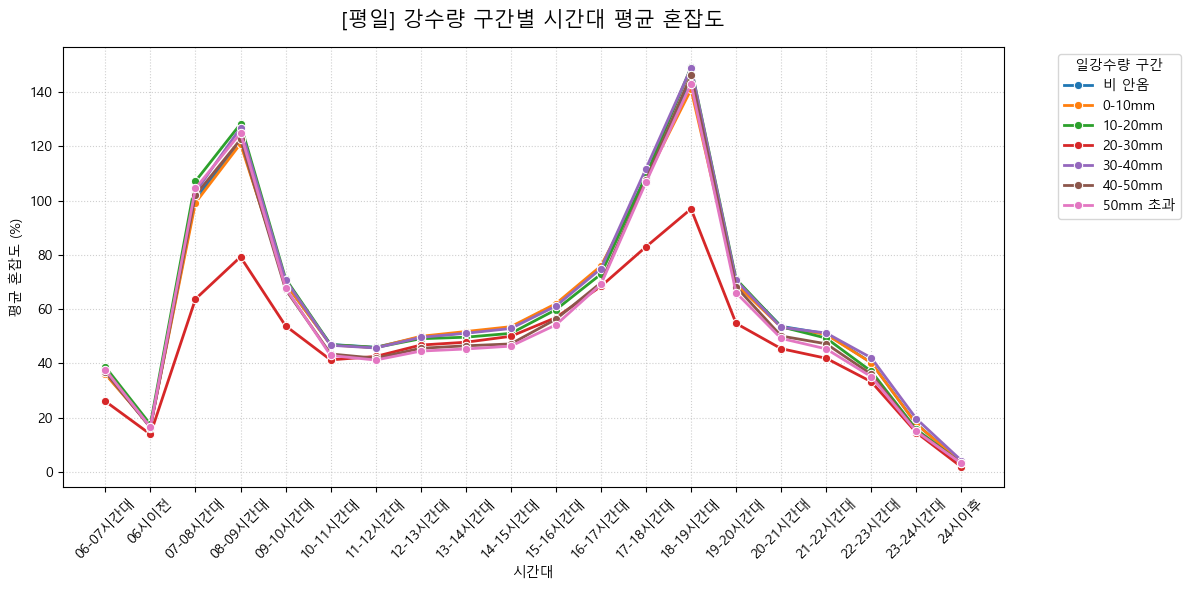

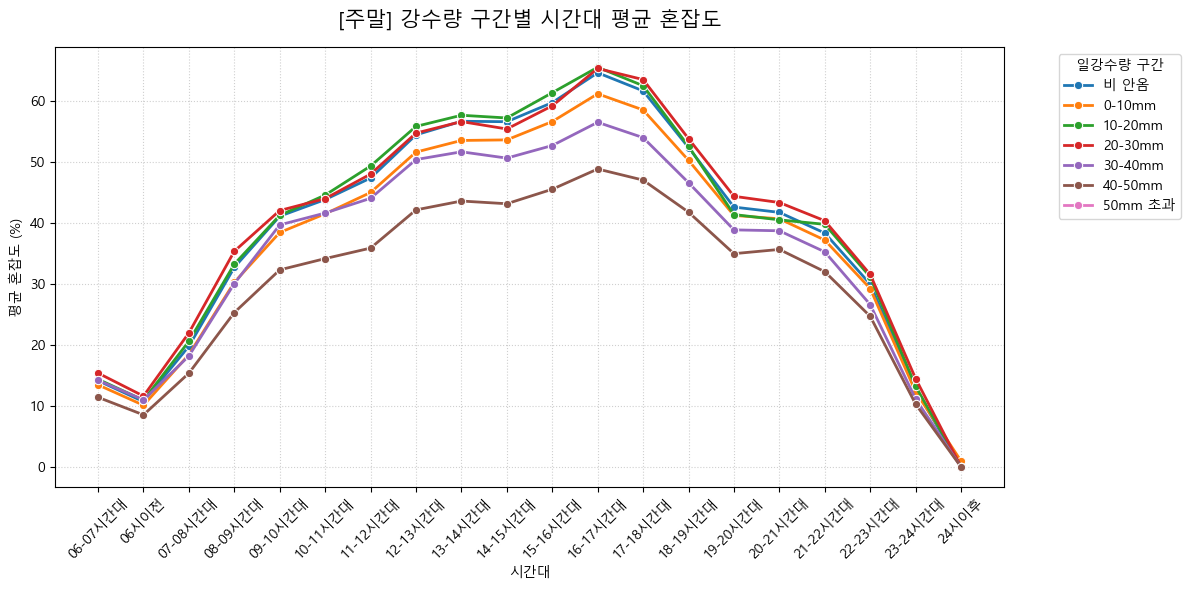

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. 데이터 불러오기 및 전처리
df_subway = pd.read_csv('서울교통공사_시간대별_추정혼잡도(%).csv', encoding='utf8')
df_weather = pd.read_csv('서울_기상데이터_2023.csv', encoding='cp949')

df_subway['수송일자'] = pd.to_datetime(df_subway['수송일자'])
df_subway['요일구분'] = df_subway['수송일자'].dt.dayofweek.apply(lambda x: '평일' if x < 5 else '주말')

# 2. 일별 강수량 합계 및 구간화
df_weather['일시'] = pd.to_datetime(df_weather['일시'])
daily_rain = df_weather.groupby(df_weather['일시'].dt.date)['강수량(mm)'].sum().reset_index()
daily_rain.columns = ['날짜', '강수량']
daily_rain['날짜'] = pd.to_datetime(daily_rain['날짜'])

bins = [0, 0.1, 10, 20, 30, 40, 50, 1000]
labels = ['비 안옴', '0-10mm', '10-20mm', '20-30mm', '30-40mm', '40-50mm', '50mm 초과']
daily_rain['강수구간'] = pd.cut(daily_rain['강수량'], bins=bins, labels=labels, include_lowest=True, right=False)

# 3. 데이터 병합 및 재구조화
merged_df = pd.merge(df_subway, daily_rain[['날짜', '강수구간']], left_on='수송일자', right_on='날짜')
time_cols = [col for col in df_subway.columns if '시간대' in col or '이전' in col or '이후' in col]
df_melted = merged_df.melt(id_vars=['요일구분', '강수구간'], value_vars=time_cols, var_name='시간대', value_name='혼잡도')
df_grouped = df_melted.groupby(['요일구분', '강수구간', '시간대'], observed=True)['혼잡도'].mean().reset_index()

# 4. 시각화 - 평일과 주말을 루프를 돌며 개별 창(Figure)에 생성
for category in ['평일', '주말']:
    # 새로운 창 생성
    plt.figure(figsize=(12, 6))
    
    # 해당 카테고리(평일 혹은 주말) 데이터만 필터링
    data_subset = df_grouped[df_grouped['요일구분'] == category]
    
    # 선 그래프 그리기
    sns.lineplot(data=data_subset, x='시간대', y='혼잡도', hue='강수구간', marker='o', linewidth=2)
    
    plt.title(f'[{category}] 강수량 구간별 시간대 평균 혼잡도', fontsize=15, pad=15)
    plt.xlabel('시간대')
    plt.ylabel('평균 혼잡도 (%)')
    plt.xticks(rotation=45)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(title='일강수량 구간', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()

# 모든 창을 한꺼번에 띄움
plt.show()

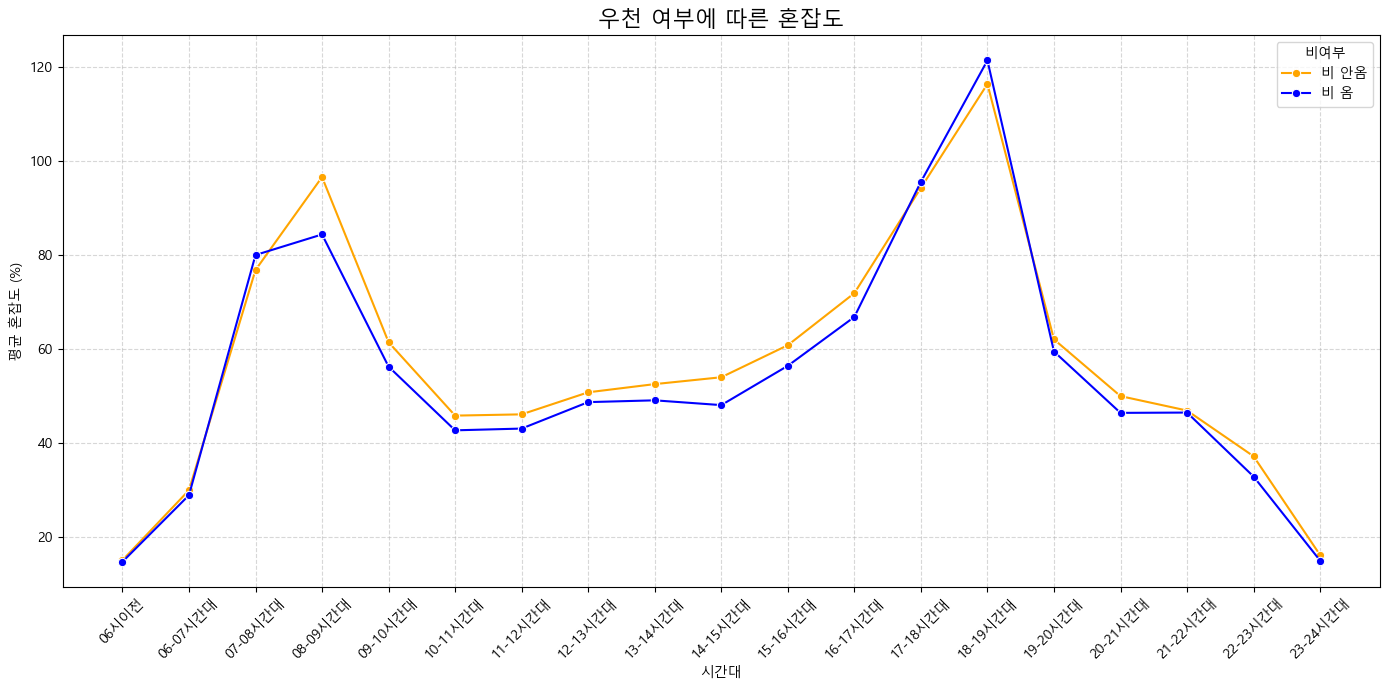

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. 데이터 불러오기
df_subway = pd.read_csv('서울교통공사_시간대별_추정혼잡도(%).csv', encoding='utf8')
df_weather = pd.read_csv('서울_기상데이터_2023.csv', encoding='cp949')

# 2. 지하철 데이터 전처리 (Melt를 통해 시간대를 행으로 변환)
df_subway['수송일자'] = pd.to_datetime(df_subway['수송일자'])
time_cols = [col for col in df_subway.columns if '시간대' in col or '이전' in col or '이후' in col]

df_sub_melted = df_subway.melt(id_vars=['수송일자', '역명', '호선'], value_vars=time_cols, 
                              var_name='시간대', value_name='혼잡도')

# '07-08시간대' 문자열에서 숫자 '7'만 추출하여 시간(hour) 정수값 생성
def extract_hour(time_str):
    if '이전' in time_str: return 5
    if '이후' in time_str: return 24
    return int(time_str[:2])

df_sub_melted['hour'] = df_sub_melted['시간대'].apply(extract_hour)

# 3. 기상 데이터 전처리
df_weather['일시'] = pd.to_datetime(df_weather['일시'])
df_weather['date'] = df_weather['일시'].dt.date
df_weather['hour'] = df_weather['일시'].dt.hour
df_weather['비여부'] = df_weather['강수량(mm)'].fillna(0).apply(lambda x: '비 옴' if x > 0 else '비 안옴')

# 4. 두 데이터 결합 (날짜와 시간이 모두 일치해야 함)
# 지하철 수송일자와 기상 date 비교를 위해 타입 맞춤
df_sub_melted['date'] = df_sub_melted['수송일자'].dt.date
merged_df = pd.merge(df_sub_melted, df_weather[['date', 'hour', '비여부']], 
                     on=['date', 'hour'], how='inner')

# 5. 시각화
plt.figure(figsize=(14, 7))
custom_palette = {'비 옴': 'blue', '비 안옴': 'orange'}

sns.lineplot(
    data=merged_df, 
    x='시간대', 
    y='혼잡도', 
    hue='비여부', 
    marker='o', 
    errorbar=None,
    palette=custom_palette  # 색상 설정 적용
)
plt.title('우천 여부에 따른 혼잡도', fontsize=16)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylabel('평균 혼잡도 (%)')
plt.tight_layout()
plt.show()

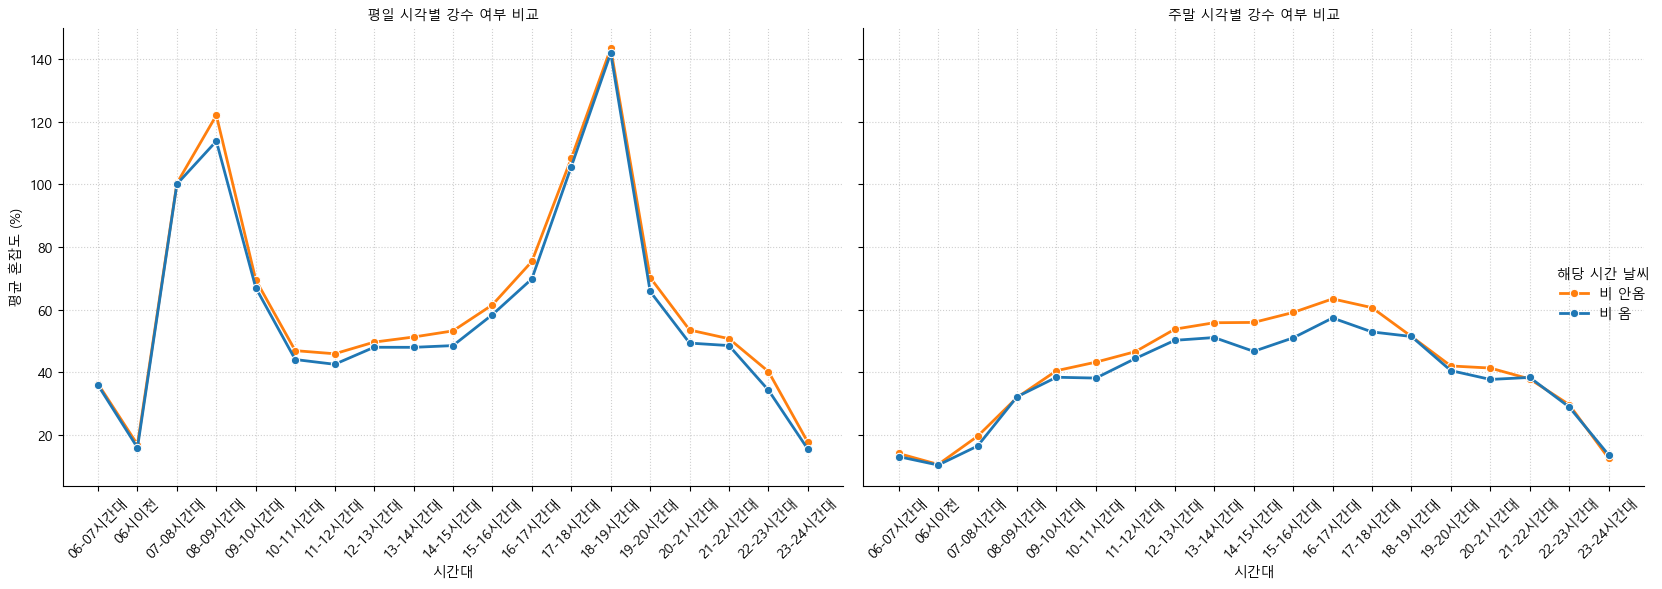

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. 데이터 불러오기
df_subway = pd.read_csv('서울교통공사_시간대별_추정혼잡도(%).csv', encoding='utf8')
df_weather = pd.read_csv('서울_기상데이터_2023.csv', encoding='cp949')

# 2. 지하철 데이터 전처리 (Melt 및 시간 정수화)
df_subway['수송일자'] = pd.to_datetime(df_subway['수송일자'])
df_subway['요일구분'] = df_subway['수송일자'].dt.dayofweek.apply(lambda x: '평일' if x < 5 else '주말')

time_cols = [col for col in df_subway.columns if '시간대' in col or '이전' in col or '이후' in col]
df_sub_melted = df_subway.melt(id_vars=['수송일자', '요일구분'], value_vars=time_cols, 
                              var_name='시간대', value_name='혼잡도')

# 시간대 텍스트에서 매칭용 'hour' 추출
def extract_hour(time_str):
    if '이전' in time_str: return 5
    if '이후' in time_str: return 24
    return int(time_str[:2])

df_sub_melted['hour'] = df_sub_melted['시간대'].apply(extract_hour)
df_sub_melted['date'] = df_sub_melted['수송일자'].dt.date

# 3. 기상 데이터 전처리 (시간별 비여부)
df_weather['일시'] = pd.to_datetime(df_weather['일시'])
df_weather['date'] = df_weather['일시'].dt.date
df_weather['hour'] = df_weather['일시'].dt.hour
df_weather['비여부'] = df_weather['강수량(mm)'].fillna(0).apply(lambda x: '비 옴' if x > 0 else '비 안옴')

# 4. 데이터 병합
merged_df = pd.merge(df_sub_melted, df_weather[['date', 'hour', '비여부']], 
                     on=['date', 'hour'], how='inner')

# 요일구분별 평균 계산
df_final = merged_df.groupby(['요일구분', '비여부', '시간대'], observed=True)['혼잡도'].mean().reset_index()

# 5. 시각화 (평일/주말 분리)
g = sns.FacetGrid(df_final, col="요일구분", hue="비여부", height=6, aspect=1.3, 
                  palette=['#ff7f0e', '#1f77b4'], col_order=['평일', '주말'])

g.map(sns.lineplot, "시간대", "혼잡도", marker='o', linewidth=2)

g.add_legend(title="해당 시간 날씨")
g.set_axis_labels("시간대", "평균 혼잡도 (%)")
g.set_titles("{col_name} 시각별 강수 여부 비교")

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()